# 06_classical_baseline_inverse_v2.ipynb

Улучшенная версия классического baseline для задачи **sensor -> speed**.

## Что изменено относительно v1
- loss считается в **residual space**:
  \[
  M_{res}(c) = F(c) - M_{hom}
  \]
- используется **более сильная smoothness regularization**;
- маска вокруг self-receiver расширена;
- оптимизация делается в режиме **coarse-to-fine**:
  - `16x16`
  - `24x24`
  - `32x32`
- на каждом уровне свой learning rate и число шагов.

## Цель
Не сделать идеальный классический inversion, а получить **более честный и устойчивый physics-based baseline**,
который хотя бы восстанавливает грубую форму и даёт меньше артефактов, чем v1.

## 0. Важно про JAX
Эта ячейка должна выполняться **в свежем kernel**, до любого `import jax`.

Если в текущем kernel JAX уже импортировался, лучше перезапустить kernel и начать с начала.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".50"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import jit, value_and_grad
from jax.image import resize

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [3]:
OUT_ROOT = Path("/workspace/usct_dataset_v2")
TEST_DIR = OUT_ROOT / "test"
assert TEST_DIR.exists(), TEST_DIR

test_files = sorted(TEST_DIR.glob("*.npz"))
print("test:", len(test_files))
assert len(test_files) > 0

test: 800


In [4]:
CFG = {
    "background_speed": 1500.0,
    "amplitude_limit": 90.0,
    "lambda_l2": 5e-4,
    "lambda_smooth": 5e-2,
    "mask_half_width": 4,
    "source_sigma_px": 1.8,
    "num_examples_to_run": 3,
    "example_indices_from_test": [0, 1, 2],
    "stages": [
        {"lowres_h": 16, "lowres_w": 16, "num_steps": 120, "lr": 0.08},
        {"lowres_h": 24, "lowres_w": 24, "num_steps": 140, "lr": 0.05},
        {"lowres_h": 32, "lowres_w": 32, "num_steps": 180, "lr": 0.03},
    ],
    "beta1": 0.9,
    "beta2": 0.999,
    "adam_eps": 1e-8,
    "save_run_name": "classical_baseline_inverse_v2",
}
CFG

{'background_speed': 1500.0,
 'amplitude_limit': 90.0,
 'lambda_l2': 0.0005,
 'lambda_smooth': 0.05,
 'mask_half_width': 4,
 'source_sigma_px': 1.8,
 'num_examples_to_run': 3,
 'example_indices_from_test': [0, 1, 2],
 'stages': [{'lowres_h': 16, 'lowres_w': 16, 'num_steps': 120, 'lr': 0.08},
  {'lowres_h': 24, 'lowres_w': 24, 'num_steps': 140, 'lr': 0.05},
  {'lowres_h': 32, 'lowres_w': 32, 'num_steps': 180, 'lr': 0.03}],
 'beta1': 0.9,
 'beta2': 0.999,
 'adam_eps': 1e-08,
 'save_run_name': 'classical_baseline_inverse_v2'}

file: /workspace/usct_dataset_v2/test/sample_00000.npz
keys: ['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x                shape=(2, 16, 256) dtype=float32
c                shape=(192, 192) dtype=float32
receiver_y       shape=(256,) dtype=int64
receiver_x       shape=(256,) dtype=int64
source_ring_idx  shape=(16,) dtype=int64
dx               shape=(2,) dtype=float32
freq_hz          shape=(1,) dtype=float32


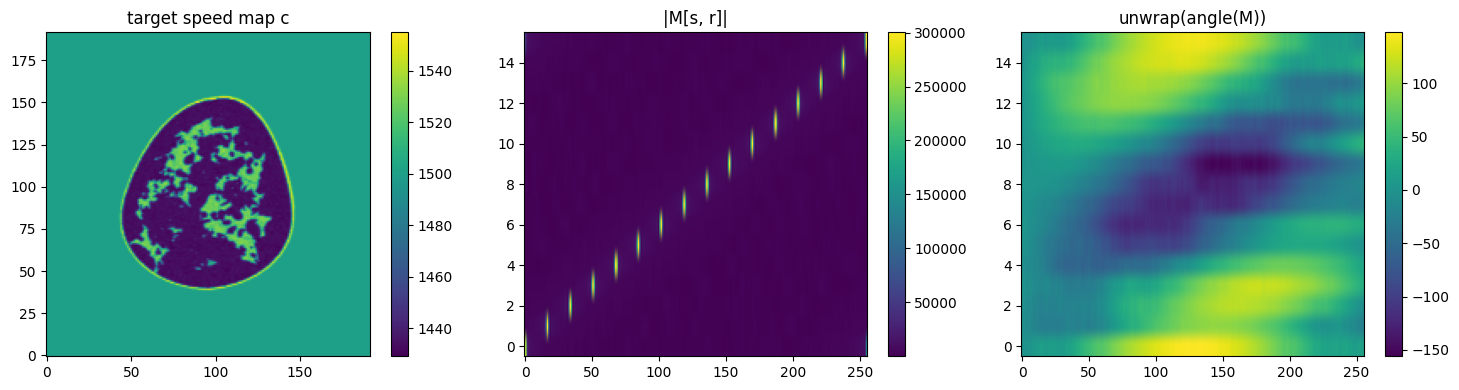

In [5]:
def inspect_npz(path: Path):
    d = np.load(path)
    print("file:", path)
    print("keys:", d.files)
    for k in d.files:
        arr = d[k]
        print(f"{k:16s} shape={arr.shape} dtype={arr.dtype}")

    x = d["x"]
    c = d["c"]
    M = x[0] + 1j * x[1]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(c, origin="lower")
    ax[0].set_title("target speed map c")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(np.abs(M), aspect="auto", origin="lower")
    ax[1].set_title("|M[s, r]|")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(np.unwrap(np.angle(M), axis=1), aspect="auto", origin="lower")
    ax[2].set_title("unwrap(angle(M))")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

inspect_npz(test_files[0])

In [6]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def mask_matrix(num_sources, num_receivers, source_ring_idx, half_width=4):
    mask = np.ones((num_sources, num_receivers), dtype=np.float32)
    for s in range(num_sources):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % num_receivers
            mask[s, rr] = 0.0
    return mask

def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

In [7]:
sample0 = np.load(test_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = jnp.array(sample0["receiver_y"].astype(np.int32))
receiver_x = jnp.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx = np.array(sample0["source_ring_idx"].astype(np.int32))

domain = Domain((H, W), dx)

source_fields = []
for ridx in source_ring_idx:
    y0 = int(sample0["receiver_y"][ridx])
    x0 = int(sample0["receiver_x"][ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=CFG["source_sigma_px"])
    source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
source_fields = tuple(source_fields)

omega = 2 * np.pi * freq_hz

print("H, W:", H, W)
print("S, R:", S, R)
print("dx:", dx)
print("freq_hz:", freq_hz)

H, W: 192 192
S, R: 16 256
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0


/tmp/ipykernel_1641/575774244.py:12: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
def forward_measurements(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(c_map, -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=1000.0,
        pml_size=16,
    )

    ms = []
    for i in range(S):
        src = FourierSeries(jnp.expand_dims(source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])

    return jnp.stack(ms, axis=0)

forward_measurements_jit = jit(forward_measurements)

M_hom shape: (16, 256) complex64
first forward time (includes JIT): 6.900711297988892 sec


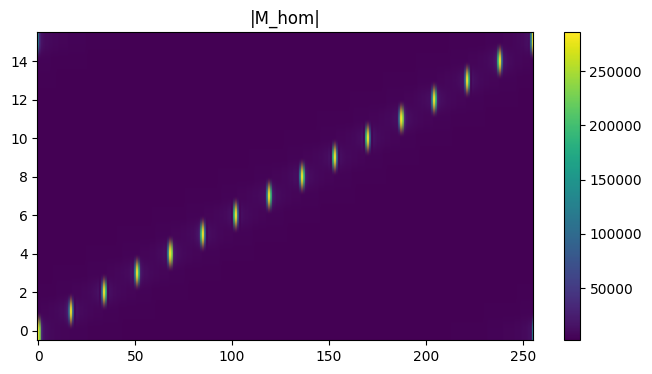

In [9]:
c_hom = jnp.full((H, W), CFG["background_speed"], dtype=jnp.float32)

t0 = time.time()
M_hom = forward_measurements_jit(c_hom)
M_hom.block_until_ready()
t1 = time.time()

print("M_hom shape:", M_hom.shape, M_hom.dtype)
print("first forward time (includes JIT):", t1 - t0, "sec")

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(np.array(M_hom)), aspect="auto", origin="lower")
plt.title("|M_hom|")
plt.colorbar()
plt.show()

In [10]:
def z_to_c(z_low):
    z_up = resize(
        z_low,
        (H, W),
        method="linear",
        antialias=False,
    )
    return CFG["background_speed"] + CFG["amplitude_limit"] * jnp.tanh(z_up)

def smoothness_penalty(c_map):
    dy = c_map[1:, :] - c_map[:-1, :]
    dx_ = c_map[:, 1:] - c_map[:, :-1]
    return jnp.mean(dy**2) + jnp.mean(dx_**2)

def make_loss_fn(M_target_complex, mask):
    mask_j = jnp.array(mask, dtype=jnp.float32)
    M_target_j = jnp.array(M_target_complex, dtype=jnp.complex64)
    M_hom_j = jnp.array(np.array(M_hom), dtype=jnp.complex64)

    def loss_fn(z_low):
        c_map = z_to_c(z_low)
        M_pred = forward_measurements_jit(c_map)

        M_pred_res = M_pred - M_hom_j
        M_target_res = M_target_j - M_hom_j

        diff = M_pred_res - M_target_res
        data_term = jnp.sum(mask_j * (jnp.abs(diff) ** 2)) / (jnp.sum(mask_j) + 1e-8)

        l2_term = jnp.mean(z_low**2)
        smooth_term = smoothness_penalty(c_map)

        return data_term + CFG["lambda_l2"] * l2_term + CFG["lambda_smooth"] * smooth_term

    return loss_fn

In [11]:
def adam_optimize(loss_fn, z0, num_steps, lr, beta1=0.9, beta2=0.999, eps=1e-8, stage_name=""):
    z = z0
    m = jnp.zeros_like(z)
    v = jnp.zeros_like(z)

    loss_and_grad = jit(value_and_grad(loss_fn))
    history = []

    for t in range(1, num_steps + 1):
        loss_val, grad = loss_and_grad(z)

        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)

        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)

        z = z - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        history.append(float(loss_val))

        if t == 1 or t % 10 == 0 or t == num_steps:
            print(f"{stage_name} step {t:4d} | loss={float(loss_val):.6f}")

    return z, history

def upsample_z(z_old, new_h, new_w):
    z_new = resize(z_old, (new_h, new_w), method="linear", antialias=False)
    return z_new.astype(jnp.float32)

In [12]:
def reconstruct_one_example_v2(npz_path: Path):
    d = np.load(npz_path)

    x = d["x"].astype(np.float32)
    c_true = d["c"].astype(np.float32)
    M_target = x[0] + 1j * x[1]
    src_idx = d["source_ring_idx"].astype(np.int32)

    mask = mask_matrix(S, R, src_idx, half_width=CFG["mask_half_width"])
    loss_fn = make_loss_fn(M_target, mask)

    stage_histories = []
    z = None

    t0 = time.time()
    for stage_id, stage in enumerate(CFG["stages"], start=1):
        sh, sw = stage["lowres_h"], stage["lowres_w"]

        if z is None:
            z = jnp.zeros((sh, sw), dtype=jnp.float32)
        else:
            z = upsample_z(z, sh, sw)

        z, hist = adam_optimize(
            loss_fn,
            z,
            num_steps=stage["num_steps"],
            lr=stage["lr"],
            beta1=CFG["beta1"],
            beta2=CFG["beta2"],
            eps=CFG["adam_eps"],
            stage_name=f"[stage {stage_id}: {sh}x{sw}]",
        )
        z.block_until_ready()
        stage_histories.append(hist)

    c_pred = np.array(z_to_c(z))
    t1 = time.time()

    return {
        "path": str(npz_path),
        "c_true": c_true,
        "c_pred": c_pred,
        "stage_histories": stage_histories,
        "history": [v for hist in stage_histories for v in hist],
        "runtime_sec": t1 - t0,
    }

In [13]:
example_ids = CFG["example_indices_from_test"][:CFG["num_examples_to_run"]]
example_paths = [test_files[i] for i in example_ids]

print("example_paths:")
for p in example_paths:
    print(p)

example_paths:
/workspace/usct_dataset_v2/test/sample_00000.npz
/workspace/usct_dataset_v2/test/sample_00001.npz
/workspace/usct_dataset_v2/test/sample_00002.npz


[stage 1: 16x16] step    1 | loss=5485732.000000
[stage 1: 16x16] step   10 | loss=2297904.750000
[stage 1: 16x16] step   20 | loss=2028495.500000
[stage 1: 16x16] step   30 | loss=1803133.000000
[stage 1: 16x16] step   40 | loss=1723661.875000
[stage 1: 16x16] step   50 | loss=1682830.750000
[stage 1: 16x16] step   60 | loss=1665731.625000
[stage 1: 16x16] step   70 | loss=1657448.000000
[stage 1: 16x16] step   80 | loss=1654413.625000
[stage 1: 16x16] step   90 | loss=1652592.500000
[stage 1: 16x16] step  100 | loss=1651350.250000
[stage 1: 16x16] step  110 | loss=1650541.000000
[stage 1: 16x16] step  120 | loss=1649936.875000
[stage 2: 24x24] step    1 | loss=1891398.375000
[stage 2: 24x24] step   10 | loss=1526320.750000
[stage 2: 24x24] step   20 | loss=1328419.375000
[stage 2: 24x24] step   30 | loss=1262232.500000
[stage 2: 24x24] step   40 | loss=1229253.000000
[stage 2: 24x24] step   50 | loss=1207232.875000
[stage 2: 24x24] step   60 | loss=1195040.500000
[stage 2: 24x24] ste

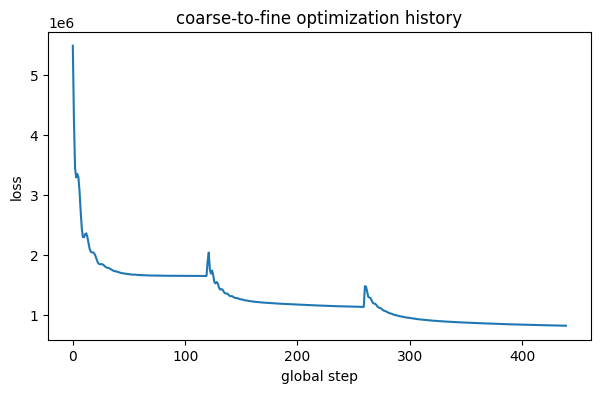

In [14]:
result0 = reconstruct_one_example_v2(example_paths[0])

print("runtime_sec:", result0["runtime_sec"])
print("final loss:", result0["history"][-1])

plt.figure(figsize=(7, 4))
plt.plot(result0["history"])
plt.xlabel("global step")
plt.ylabel("loss")
plt.title("coarse-to-fine optimization history")
plt.show()

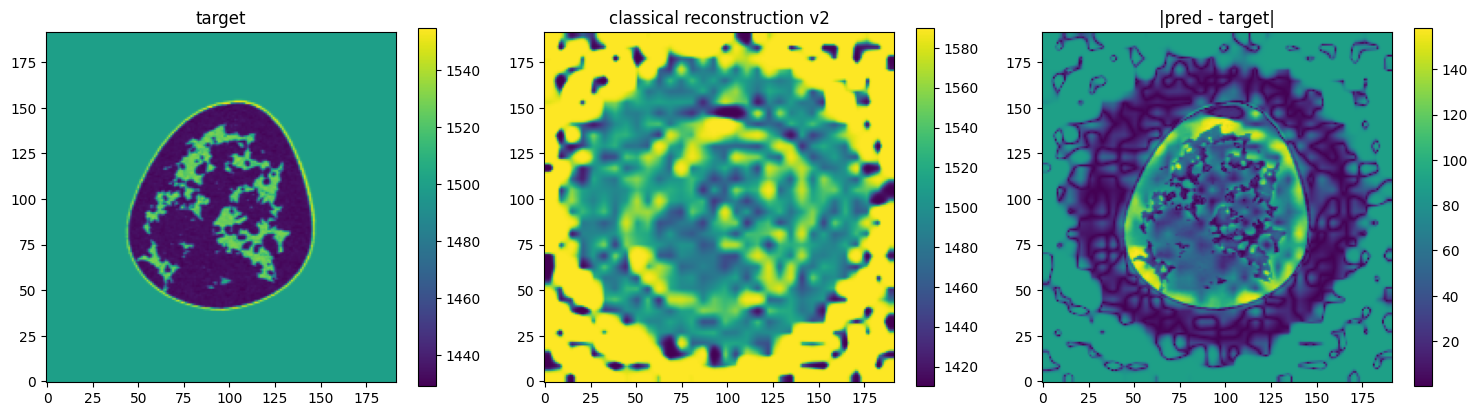

In [15]:
def show_reconstruction(result):
    c_true = result["c_true"]
    c_pred = result["c_pred"]
    err = np.abs(c_pred - c_true)

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))

    im0 = ax[0].imshow(c_true, origin="lower")
    ax[0].set_title("target")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(c_pred, origin="lower")
    ax[1].set_title("classical reconstruction v2")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(err, origin="lower")
    ax[2].set_title("|pred - target|")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

show_reconstruction(result0)

In [16]:
results = []
for p in example_paths:
    print("=" * 80)
    print("reconstructing:", p)
    res = reconstruct_one_example_v2(p)
    results.append(res)
    print("runtime_sec:", res["runtime_sec"])
    print("final loss:", res["history"][-1])

reconstructing: /workspace/usct_dataset_v2/test/sample_00000.npz
[stage 1: 16x16] step    1 | loss=5485732.000000
[stage 1: 16x16] step   10 | loss=2297904.750000
[stage 1: 16x16] step   20 | loss=2028495.500000
[stage 1: 16x16] step   30 | loss=1803133.000000
[stage 1: 16x16] step   40 | loss=1723661.875000
[stage 1: 16x16] step   50 | loss=1682830.750000
[stage 1: 16x16] step   60 | loss=1665731.625000
[stage 1: 16x16] step   70 | loss=1657448.000000
[stage 1: 16x16] step   80 | loss=1654413.625000
[stage 1: 16x16] step   90 | loss=1652592.500000
[stage 1: 16x16] step  100 | loss=1651350.250000
[stage 1: 16x16] step  110 | loss=1650541.000000
[stage 1: 16x16] step  120 | loss=1649936.875000


2026-03-20 19:08:57.403216: E external/xla/xla/stream_executor/cuda/cuda_fft.cc:253] Failed to make cuFFT batched plan: 5
2026-03-20 19:08:57.403236: E external/xla/xla/stream_executor/cuda/cuda_fft.cc:320] Initialize Params: rank: 1 elem_count: 192 input_embed: 192 input_stride: 1 input_distance: 192 output_embed: 192 output_stride: 1 output_distance: 192 batch_count: 192
2026-03-20 19:08:57.403241: E external/xla/xla/stream_executor/cuda/cuda_fft.cc:329] Failed to initialize batched cufft plan with customized allocator: Failed to make cuFFT batched plan.
2026-03-20 19:08:57.403504: E external/xla/xla/status_macros.cc:55] INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/runtime/fft_thunk.cc:176) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator
*** Begin stack trace ***
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	
	PyObject_Vectorcall
	_PyEval_EvalFrameDefault
	_PyObject_FastCallDictTstate
	_PyObject_Call_Prepend
	
	_PyObject_Call
	_PyEval_Ev

XlaRuntimeError: INTERNAL: RET_CHECK failure (external/xla/xla/service/gpu/runtime/fft_thunk.cc:176) fft_plan != nullptr Failed to create cuFFT batched plan with scratch allocator

In [ ]:
for res in results:
    show_reconstruction(res)

In [ ]:
data_range = float(
    np.max([r["c_true"].max() for r in results]) - np.min([r["c_true"].min() for r in results])
)

metrics_list = []
for i, res in enumerate(results):
    m = compute_metrics(res["c_pred"], res["c_true"], data_range=data_range)
    m["index"] = i
    m["path"] = res["path"]
    m["runtime_sec"] = float(res["runtime_sec"])
    metrics_list.append(m)

summary = {}
for key in metrics_list[0].keys():
    if key in ("index", "path"):
        continue
    vals = [m[key] for m in metrics_list]
    summary[f"{key}_mean"] = float(np.mean(vals))
    summary[f"{key}_std"] = float(np.std(vals))

print("CLASSICAL BASELINE V2 SUMMARY")
print(json.dumps(summary, ensure_ascii=False, indent=2))

In [ ]:
RUN_NAME = CFG["save_run_name"]
OUT_DIR = Path("/workspace/reference_points") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

config_to_save = {
    "run_name": RUN_NAME,
    "description": "Improved classical inverse baseline with residual objective and coarse-to-fine optimization",
    "num_examples": len(results),
    "example_indices_from_test": example_ids,
    "cfg": CFG,
    "H": H,
    "W": W,
    "S": S,
    "R": R,
    "freq_hz": float(freq_hz),
    "dx": [float(x) for x in dx],
}

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_full.json", "w", encoding="utf-8") as f:
    json.dump(metrics_list, f, ensure_ascii=False, indent=2)

for i, res in enumerate(results):
    np.savez_compressed(
        OUT_DIR / f"reconstruction_{i:02d}.npz",
        c_true=res["c_true"].astype(np.float32),
        c_pred=res["c_pred"].astype(np.float32),
        history=np.array(res["history"], dtype=np.float32),
        runtime_sec=np.array([res["runtime_sec"]], dtype=np.float32),
    )

print("saved results to:", OUT_DIR)